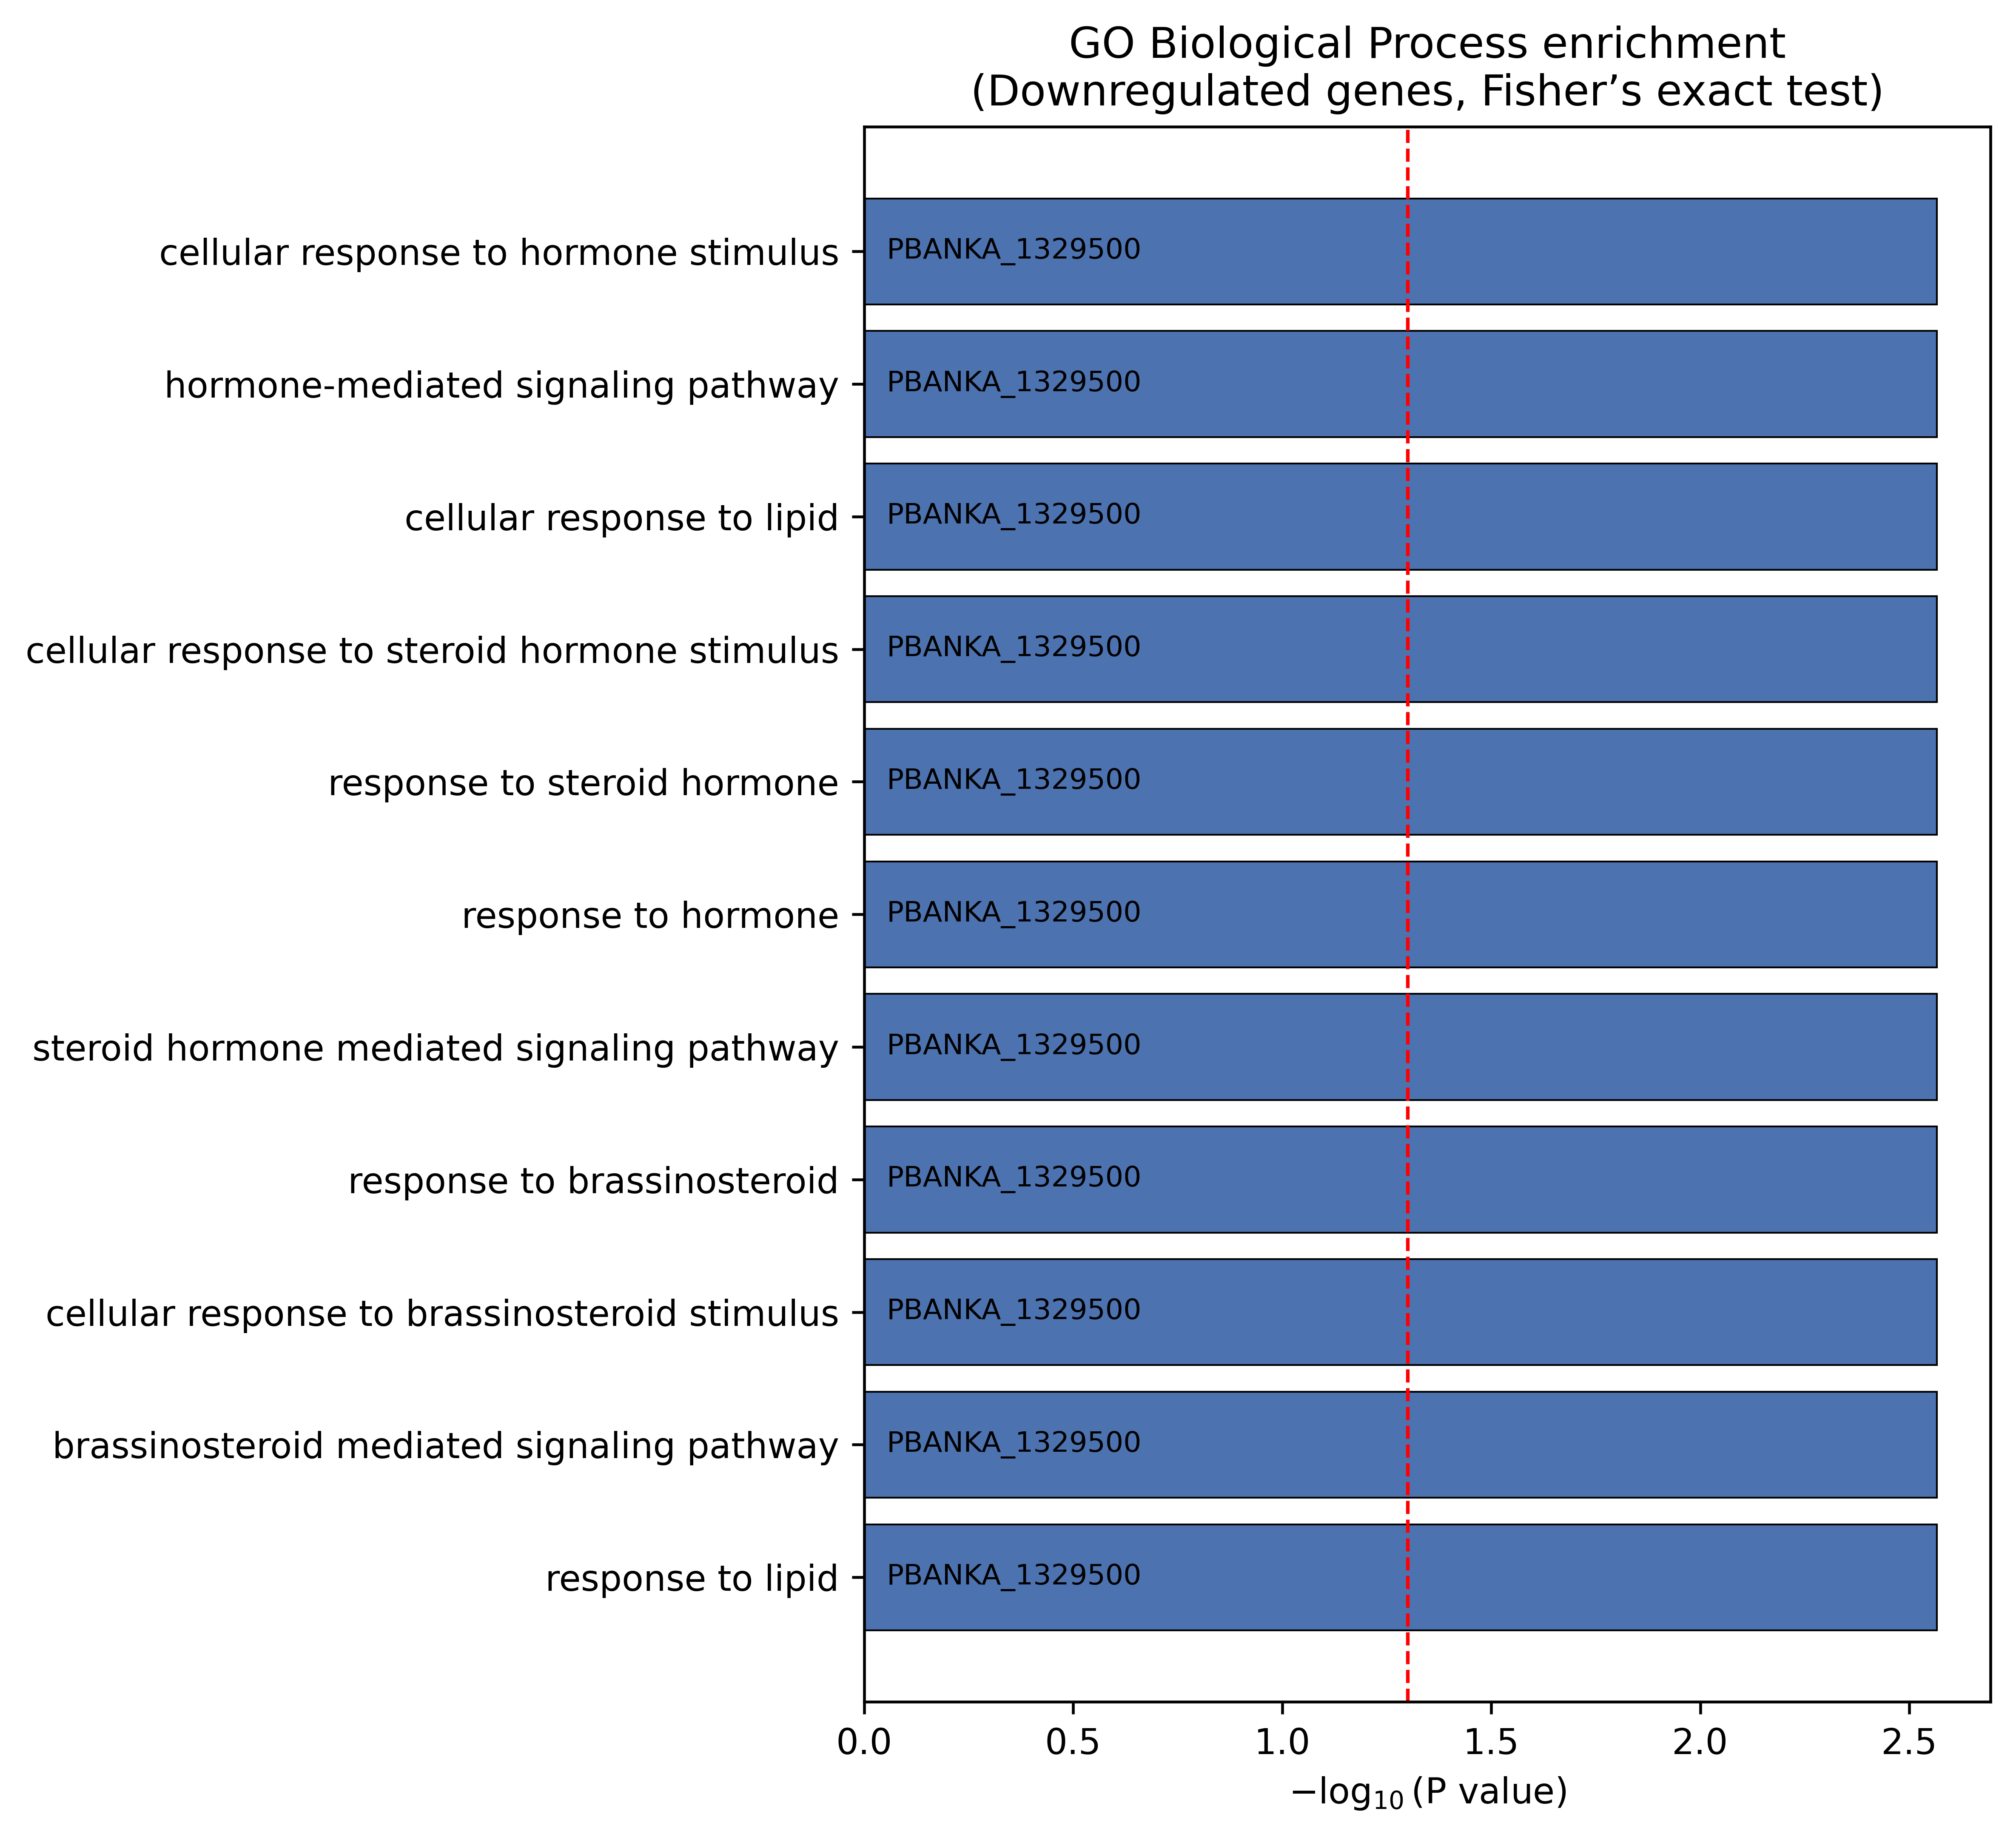

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load enrichment table
df = pd.read_csv("down_plasmodb_enrichment.tsv", sep="\t")

# Ensure numeric columns
df["P-value"] = pd.to_numeric(df["P-value"], errors="coerce")
df["Benjamini"] = pd.to_numeric(df["Benjamini"], errors="coerce")

# Sort by raw p-value
df = df.sort_values("P-value", ascending=True)

# Compute -log10(p)
df["neglog10_p"] = -np.log10(df["P-value"])

# Color by BH significance
colors = np.where(df["Benjamini"] < 0.05, "#4C72B0", "#B0B0B0")

# Plot
plt.figure(figsize=(8, 4 + 0.3 * len(df)))

bars = plt.barh(
    df["Name"],
    df["neglog10_p"],
    color=colors,
    edgecolor="black",
    linewidth=0.5
)

# Significance threshold line (p = 0.05)
plt.axvline(-np.log10(0.05), color="red", linestyle="--", linewidth=1)

plt.xlabel(r"$-\log_{10}(\mathrm{P\ value})$")
plt.title("GO Biological Process enrichment\n(Downregulated genes, Fisher’s exact test)")

# Annotate gene drivers safely
for bar, genes in zip(bars, df["Result gene list"]):
    gene_list = ", ".join(g.strip() for g in genes.split(",") if g.strip())
    plt.text(
        0.02 * plt.xlim()[1],
        bar.get_y() + bar.get_height() / 2,
        gene_list,
        va="center",
        fontsize=8
    )

# Most significant at top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("down_go_enrichment_barplot.png", dpi=300)
plt.savefig("down_go_enrichment_barplot.pdf")
plt.show()


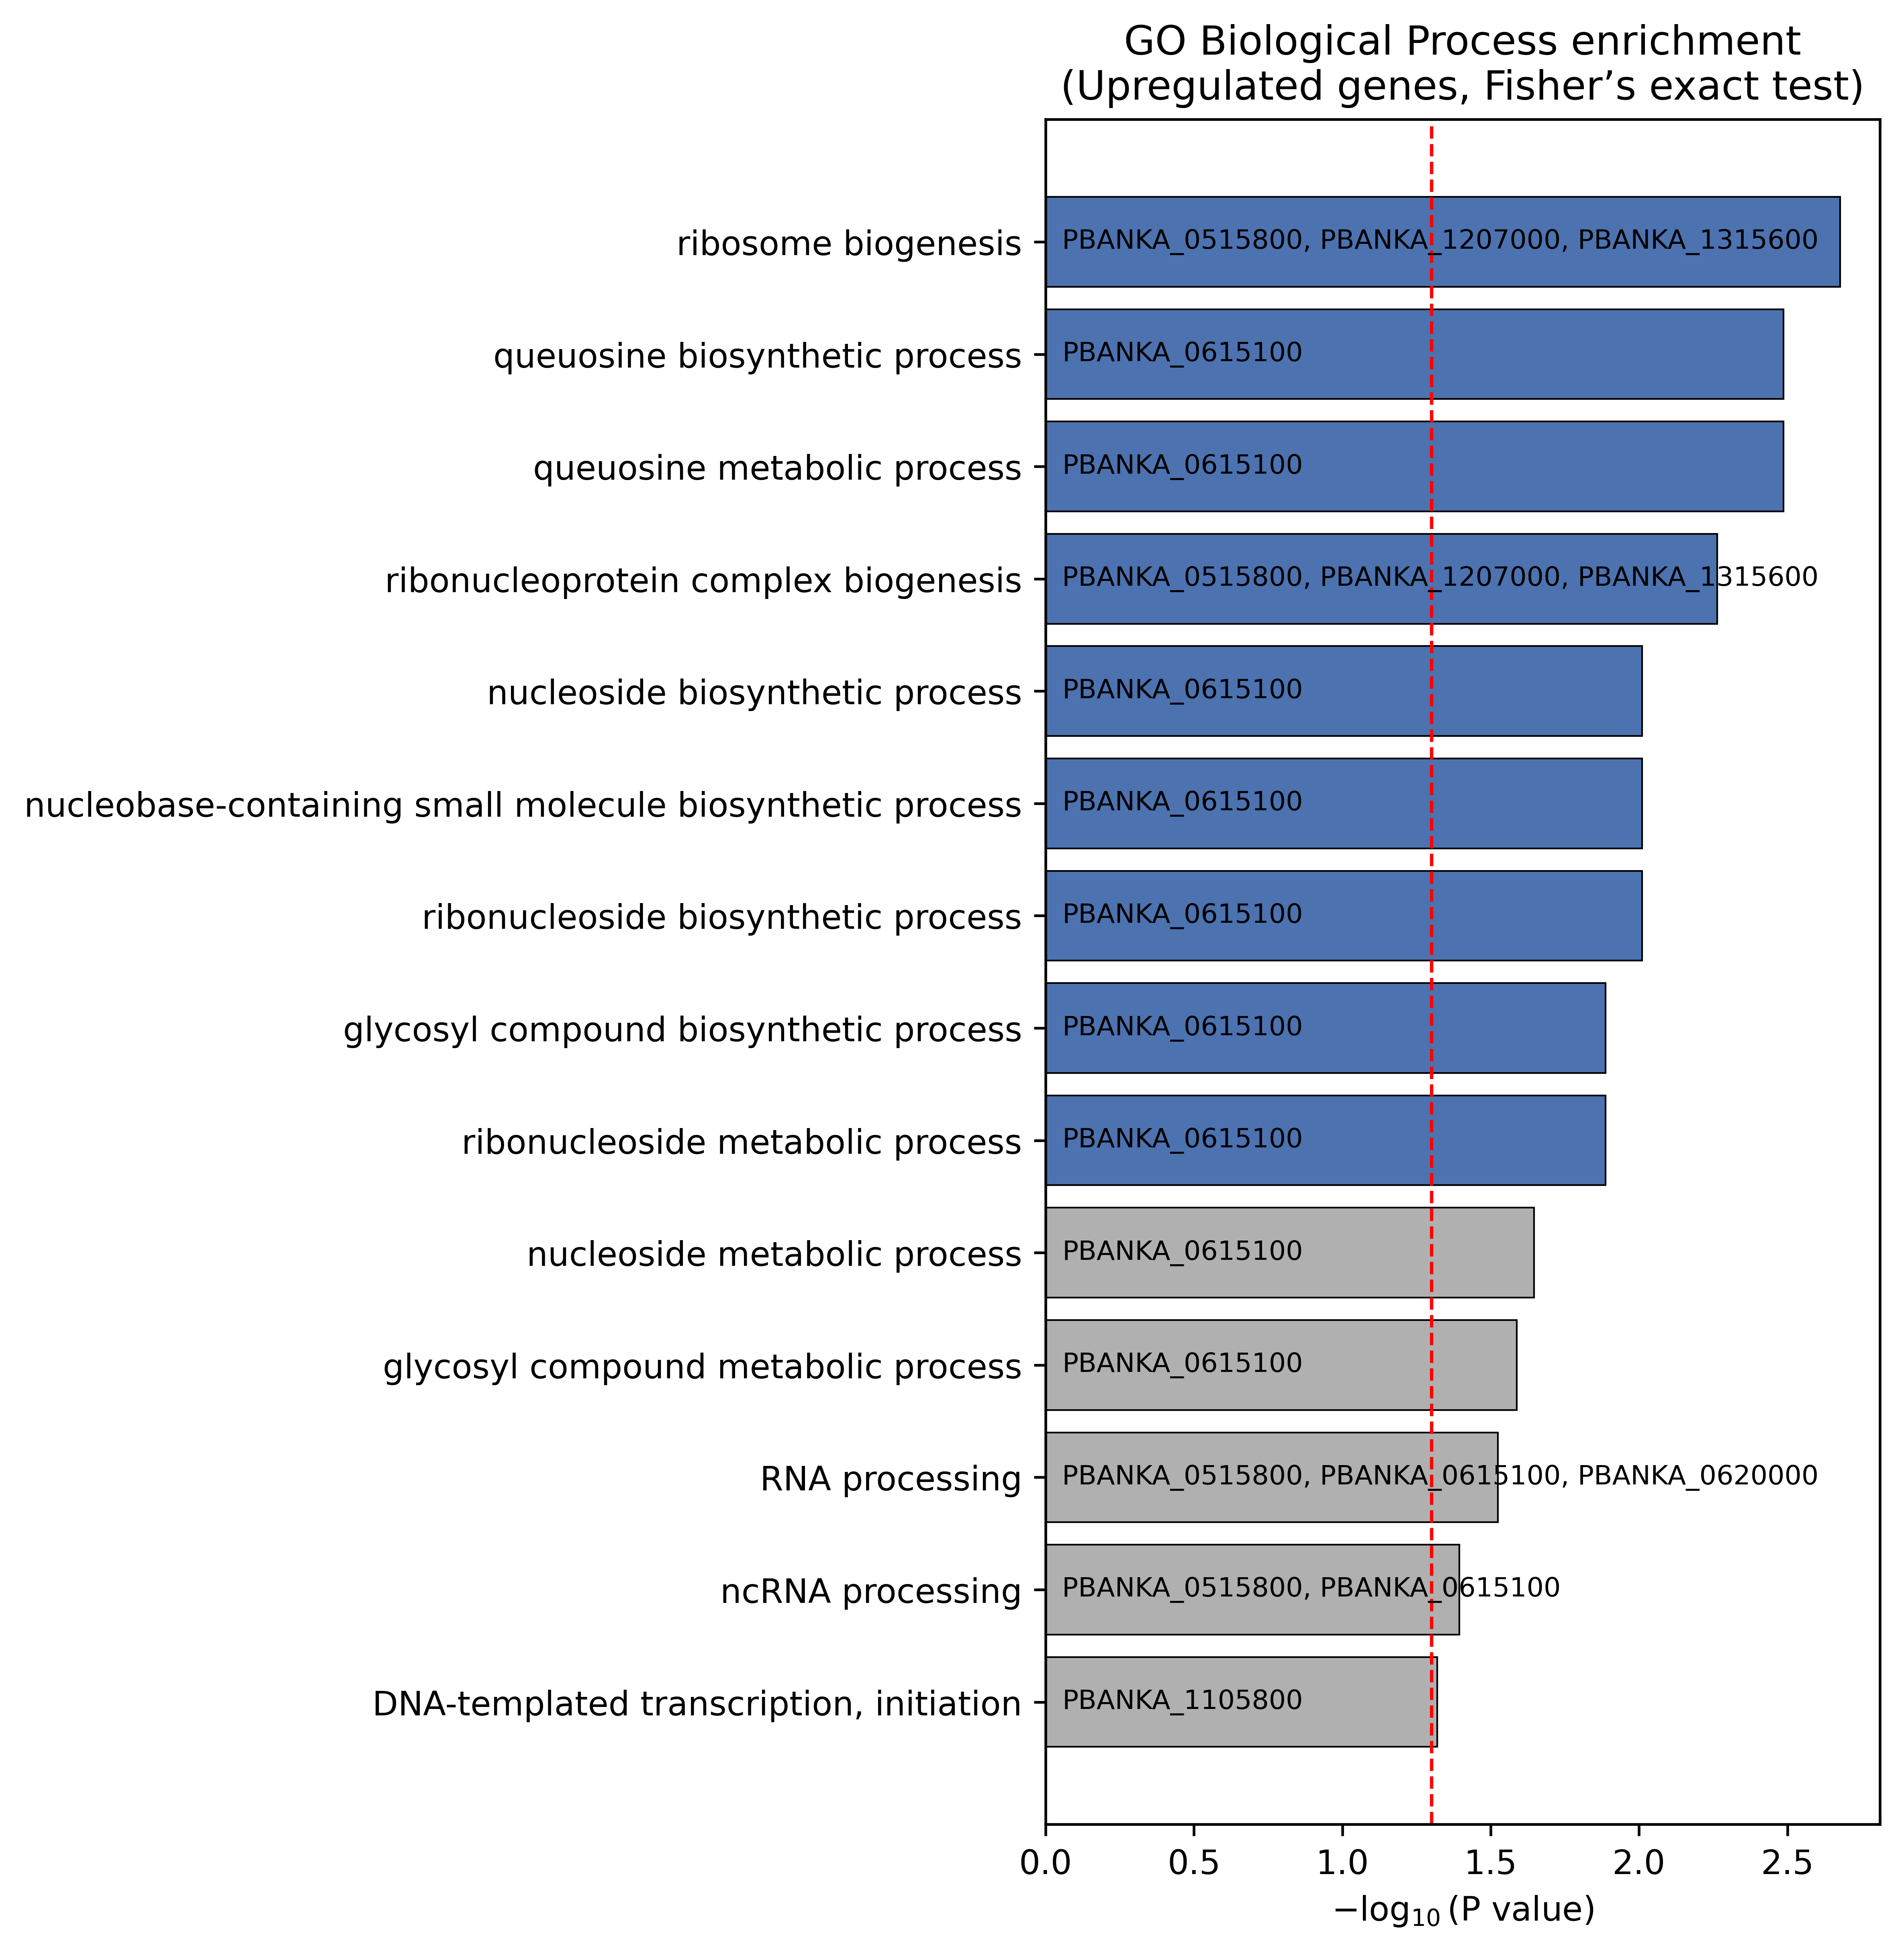

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load enrichment table
df = pd.read_csv("up_plasmodb_enrichment.tsv", sep="\t")

# Ensure numeric columns
df["P-value"] = pd.to_numeric(df["P-value"], errors="coerce")
df["Benjamini"] = pd.to_numeric(df["Benjamini"], errors="coerce")

# Sort by raw p-value
df = df.sort_values("P-value", ascending=True)

# Compute -log10(p)
df["neglog10_p"] = -np.log10(df["P-value"])

# Color by BH significance
colors = np.where(df["Benjamini"] < 0.05, "#4C72B0", "#B0B0B0")

# Plot
plt.figure(figsize=(8, 4 + 0.3 * len(df)))

bars = plt.barh(
    df["Name"],
    df["neglog10_p"],
    color=colors,
    edgecolor="black",
    linewidth=0.5
)

# Significance threshold line (p = 0.05)
plt.axvline(-np.log10(0.05), color="red", linestyle="--", linewidth=1)

plt.xlabel(r"$-\log_{10}(\mathrm{P\ value})$")
plt.title("GO Biological Process enrichment\n(Upregulated genes, Fisher’s exact test)")

# Annotate gene drivers safely
for bar, genes in zip(bars, df["Result gene list"]):
    gene_list = ", ".join(g.strip() for g in genes.split(",") if g.strip())
    plt.text(
        0.02 * plt.xlim()[1],
        bar.get_y() + bar.get_height() / 2,
        gene_list,
        va="center",
        fontsize=8
    )

# Most significant at top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("up_go_enrichment_barplot.png", dpi=300)
plt.savefig("up_go_enrichment_barplot.pdf")
plt.show()
